In [ ]:
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical

In [ ]:
# ── 1. Load dataset ──────────────────────────────────────────────────────────
data = pd.read_csv("/content/drive/MyDrive/Dataset/A_Z Handwritten Data.csv").astype('float32')

In [ ]:
X = data.drop('0', axis=1)
y = data['0']

In [ ]:
# ── 2. Train / test split ────────────────────────────────────────────────────
train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
train_x = np.reshape(train_x.values, (train_x.shape[0], 28, 28))
test_x  = np.reshape(test_x.values,  (test_x.shape[0],  28, 28))

In [ ]:
print("Train data shape:", train_x.shape)
print("Test  data shape:", test_x.shape)

Train data shape: (297960, 28, 28)
Test  data shape: (74490, 28, 28)


In [ ]:
# ── 3. Label dictionary ──────────────────────────────────────────────────────
word_dict = {i: chr(65 + i) for i in range(26)}

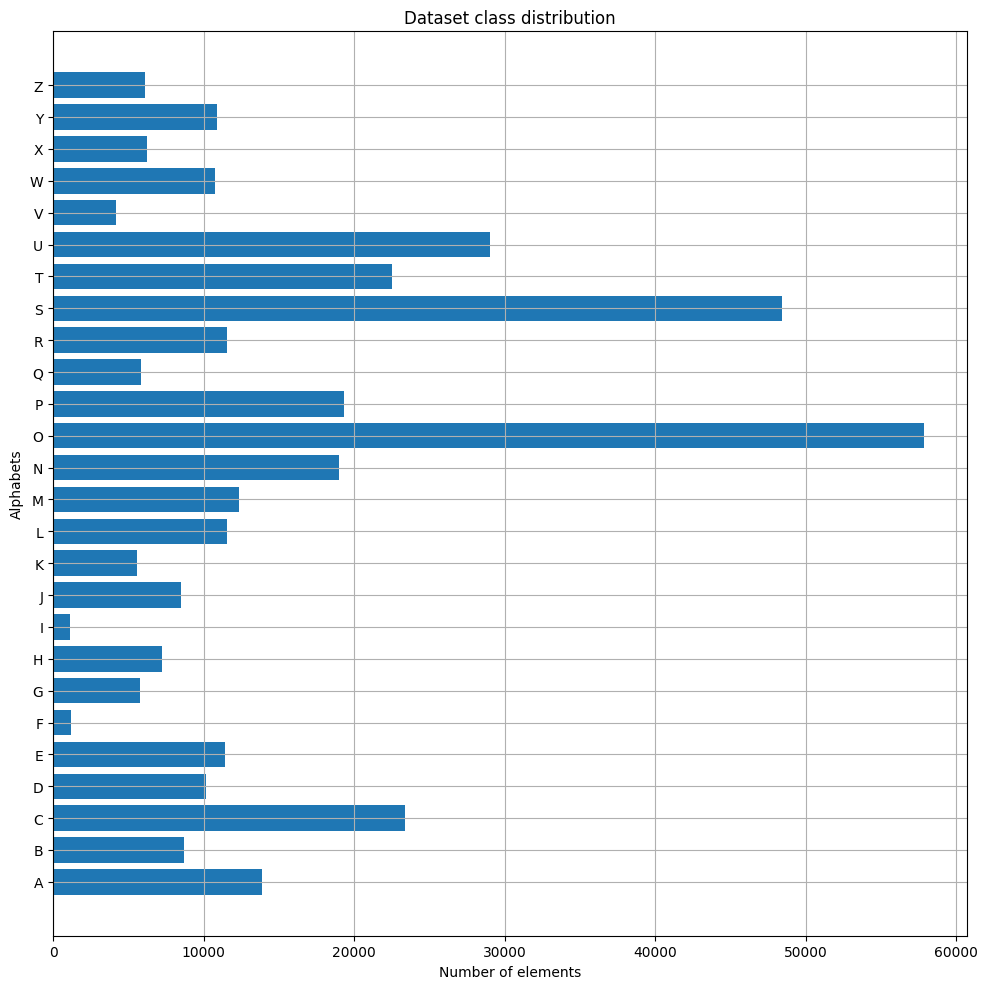

In [ ]:
# ── 4. Class distribution plot ───────────────────────────────────────────────
train_yint = y.astype(int)
count      = np.bincount(train_yint, minlength=26)
alphabets  = list(word_dict.values())

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(alphabets, count)
plt.xlabel("Number of elements")
plt.ylabel("Alphabets")
plt.title("Dataset class distribution")
plt.grid()
plt.tight_layout()
plt.show()

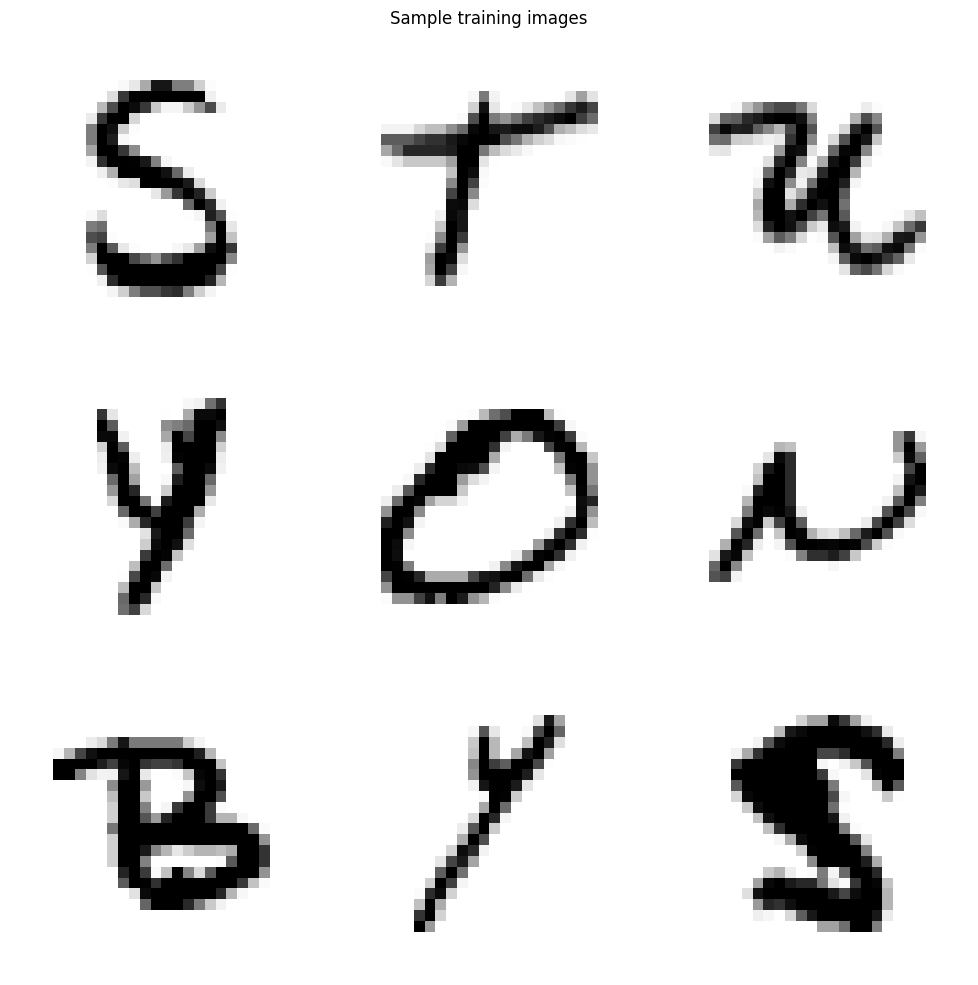

In [ ]:
# ── 5. Preview shuffled samples ──────────────────────────────────────────────
shuff = shuffle(train_x[:100])
fig, ax = plt.subplots(3, 3, figsize=(10, 10))
axes = ax.flatten()
for i in range(9):
    axes[i].imshow(np.reshape(shuff[i], (28, 28)), cmap="Greys")
    axes[i].axis('off')
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

In [ ]:
# ── 6. Add channel dim + NORMALIZE to [0, 1] ────────────────────────────────
#    the external image preprocessing. Without this the model sees a completely
#    different value range at prediction time → wrong predictions guaranteed.
train_X = train_x.reshape(train_x.shape[0], 28, 28, 1) / 255.0
test_X  = test_x.reshape(test_x.shape[0],  28, 28, 1) / 255.0

print("New shape of train data:", train_X.shape)
print("New shape of test  data:", test_X.shape)

New shape of train data: (297960, 28, 28, 1)
New shape of test  data: (74490, 28, 28, 1)


In [ ]:
# ── 7. One-hot encode labels ─────────────────────────────────────────────────
train_yOHE = to_categorical(train_y, num_classes=26)
test_yOHE  = to_categorical(test_y,  num_classes=26)

print("Train labels shape:", train_yOHE.shape)
print("Test  labels shape:", test_yOHE.shape)

Train labels shape: (297960, 26)
Test  labels shape: (74490, 26)


In [ ]:
# ── 8. Build CNN ─────────────────────────────────────────────────────────────
model = Sequential([
    Conv2D(32,  (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPool2D((2, 2), strides=2),

    Conv2D(64,  (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2), strides=2),

    Conv2D(128, (3, 3), activation='relu', padding='valid'),
    MaxPool2D((2, 2), strides=2),

    Flatten(),
    Dense(64,  activation='relu'),
    Dense(128, activation='relu'),
    Dense(26,  activation='softmax'),
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,178 (535.85 KB)

 Trainable params: 137,178 (535.85 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── 9. Train ─────────────────────────────────────────────────────────────────
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=0.0001)
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=2, verbose=1, mode='auto')
history = model.fit(
    train_X, train_yOHE,
    epochs=10,
    batch_size=256,
    callbacks=[reduce_lr, early_stop],
    validation_data=(test_X, test_yOHE)
)
model.save('the_model.h5')
print("Model saved.")

Epoch 1/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9331 - loss: 0.2334 - val_accuracy: 0.9778 - val_loss: 0.0797 - learning_rate: 0.0010
Epoch 2/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9814 - loss: 0.0661 - val_accuracy: 0.9824 - val_loss: 0.0611 - learning_rate: 0.0010
Epoch 3/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9858 - loss: 0.0497 - val_accuracy: 0.9853 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 4/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9883 - loss: 0.0406 - val_accuracy: 0.9866 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 5/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9901 - loss: 0.0338 - val_accuracy: 0.9881 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 6/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9914 - loss: 0.0287 - val_accuracy: 0.9903 - val_loss: 0.0365 - learning_rate: 0.0010
Epoch 7/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.992

✅ Model saved.


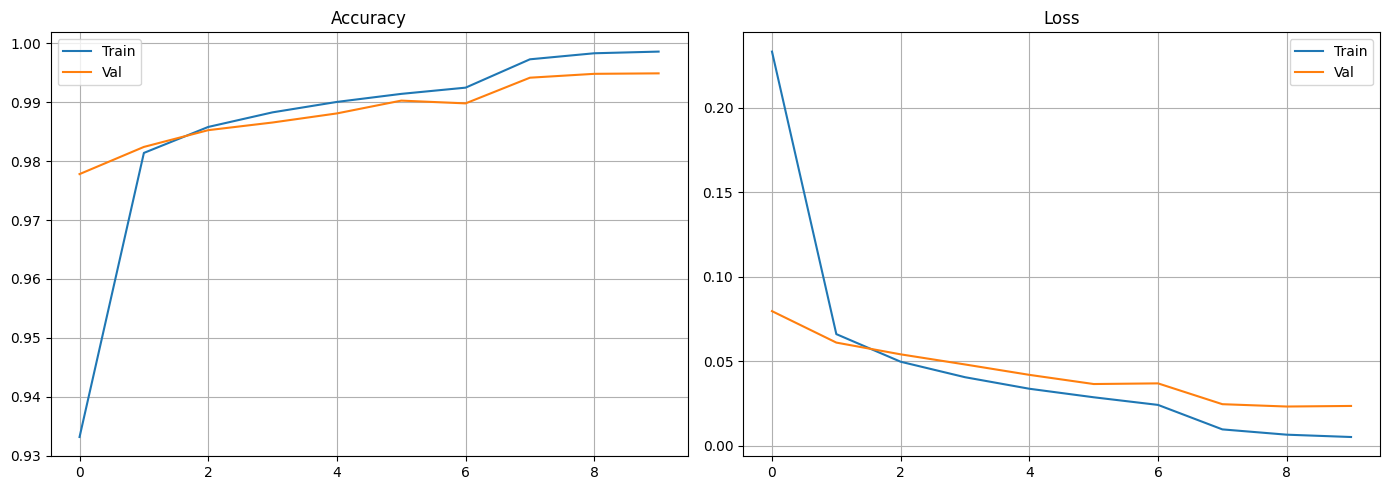

Validation accuracy: [0.9778091311454773, 0.982427179813385, 0.9852731823921204, 0.9865753650665283, 0.9881191849708557, 0.9902939796447754, 0.989824116230011, 0.9941871166229248, 0.9948449730873108, 0.9949254989624023]
Training   accuracy: [0.9331420063972473, 0.9814069271087646, 0.9858202338218689, 0.9883004426956177, 0.99007248878479, 0.9914384484291077, 0.9924956560134888, 0.9973117113113403, 0.9983386993408203, 0.9986206293106079]
Validation loss    : [0.07970362901687622, 0.06108517199754715, 0.054126203060150146, 0.04813677445054054, 0.04198111221194267, 0.03654967620968819, 0.03693394362926483, 0.024613868445158005, 0.023230455815792084, 0.023571575060486794]
Training   loss    : [0.23337048292160034, 0.06610002368688583, 0.04974867403507233, 0.040590424090623856, 0.0337529331445694, 0.02870638109743595, 0.024186642840504646, 0.009694024920463562, 0.006561275105923414, 0.00518274400383234]


In [ ]:
# ── 10.Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy');  axes[0].legend();  axes[0].grid()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss');  axes[1].legend();  axes[1].grid()

plt.tight_layout()
plt.show()

print("Validation accuracy:", history.history['val_accuracy'])
print("Training   accuracy:", history.history['accuracy'])
print("Validation loss    :", history.history['val_loss'])
print("Training   loss    :", history.history['loss'])

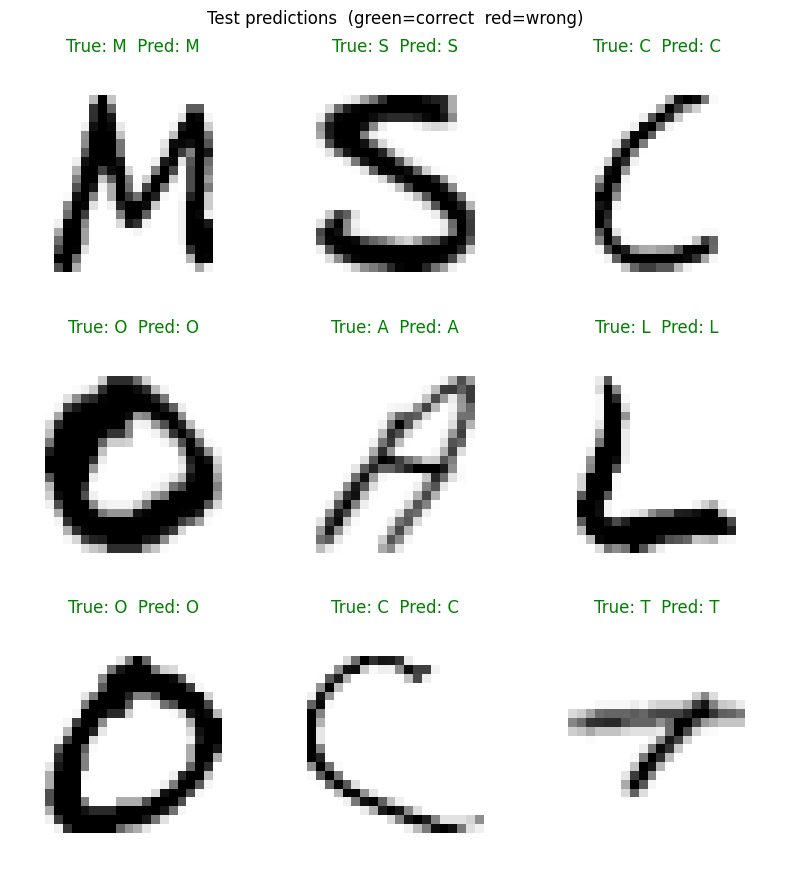

In [ ]:
# ── 11. Predict on 9 test samples ────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(8, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = np.reshape(test_X[i], (28, 28))
    ax.imshow(img, cmap="Greys")
    true_lbl = word_dict[np.argmax(test_yOHE[i])]
    pred_lbl = word_dict[np.argmax(model.predict(test_X[i:i+1], verbose=0))]
    ax.set_title(f"True: {true_lbl}  Pred: {pred_lbl}",
                 color='green' if true_lbl == pred_lbl else 'red')
    ax.axis('off')

plt.suptitle("Test predictions  (green=correct  red=wrong)")
plt.tight_layout()
plt.show()

In [ ]:
img_raw = cv2.imread("/content/drive/MyDrive/test_caracter/caracter.png", cv2.IMREAD_GRAYSCALE)

✅ Predicted character : S  (confidence: 100.0%)


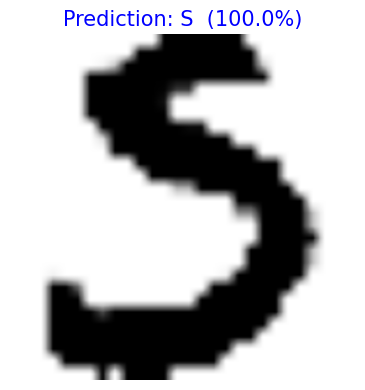

In [ ]:
if img_raw is None:
    print("Image not found — check the path.")
else:
    #    Resizing first shrinks strokes to 1-pixel width; thresholding then
    #    destroys them. Correct order: threshold → resize.
    _, img_thresh = cv2.threshold(img_raw, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Make sure the character is WHITE on BLACK (matches training data)
    if np.mean(img_thresh) > 127:
        img_thresh = cv2.bitwise_not(img_thresh)

    img_28 = cv2.resize(img_thresh, (28, 28))

    # ✅#1 (continued) — normalize to [0,1] exactly as training data
    img_final = img_28.reshape(1, 28, 28, 1) / 255.0

    # Predict
    pred      = model.predict(img_final, verbose=0)
    img_pred  = word_dict[np.argmax(pred)]
    confidence = np.max(pred) * 100

    print(f"✅ Predicted character : {img_pred}  (confidence: {confidence:.1f}%)")

    # Display with matplotlib (cv2.imshow not supported in Colab)
    img_display = cv2.resize(img_28, (280, 280))

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display, cmap='Greys')
    plt.title(f"Prediction: {img_pred}  ({confidence:.1f}%)", fontsize=15, color='blue')
    plt.axis('off')
    plt.tight_layout()
    plt.show()